# Part 3 — Community Detection

Reference: SNA Final Project guidelines, Part 3 (Cluster 1, Data Analysis).

Each group must address at least $N-1$ tasks; here $N=2$ so we address one task. We pick **Community Detection** because:

- the giant connected component covers 97.6% of the network and is large enough for meaningful modular structure;
- the edge attribute `sentiment_roberta` gives us a *semantic* lens through which to interpret the partitions, which is exactly what the project guidelines require in Part 5;
- the resulting community labels feed directly into the Open Question of Part 4 (intra- vs inter-community sentiment, echo chambers).

Sections:
1. Setup and graph loading
2. Algorithms: Louvain, Leiden, Infomap, Label Propagation
3. Internal evaluation (modularity, conductance, internal density, sizes)
4. Cross-algorithm comparison (NMI, ARI)
5. Semantic interpretation (top hubs and sentiment per community)
6. Persistence for Part 4

## 1. Setup and graph loading

We work on the **simple, undirected, unweighted** projection $G$ produced in Part 2 and restrict the analysis to its giant connected component (GCC). Edge `sentiment_roberta` and `interaction_weight` are kept as attributes for semantic interpretation, while the community detection algorithms run on plain topology.

In [1]:
import os, json, ast, random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RNG_SEED = 42
random.seed(RNG_SEED); np.random.seed(RNG_SEED)

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Preferred input: graph already enriched with Part-2 centralities. Fallback: roberta_final.
INPUT_CANDIDATES = [
    'private/dataset_part2_with_centralities.gexf',
    # 'private/dataset_roberta_final.gexf',
]
INPUT_FILE = next(f for f in INPUT_CANDIDATES if os.path.exists(f))
print(f'Loading: {INPUT_FILE}')
G_dir = nx.read_gexf(INPUT_FILE)

Loading: private/dataset_part2_with_centralities.gexf


In [2]:
# Build undirected, simple graph; preserve edge sentiment/interaction metadata.
edge_sentiment_sum = defaultdict(float)
edge_weight = defaultdict(int)

G = nx.Graph()
G.add_nodes_from(G_dir.nodes(data=True))
for u, v, data in G_dir.edges(data=True):
    if u == v:
        continue
    key = tuple(sorted((u, v)))
    s = float(data.get('sentiment_roberta', 0.0))
    w = int(data.get('interaction_weight', data.get('weight', 1)))
    edge_sentiment_sum[key] += s * w
    edge_weight[key] += w

for (u, v), w in edge_weight.items():
    G.add_edge(
        u,
        v,
        sentiment_roberta=edge_sentiment_sum[(u, v)] / w,
        interaction_weight=w,
    )

edge_sentiment = {
    key: edge_sentiment_sum[key] / edge_weight[key]
    for key in edge_sentiment_sum
}

# Restrict to GCC
gcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(gcc_nodes).copy()

edge_sentiment = {
    key: value
    for key, value in edge_sentiment.items()
    if G.has_edge(*key)
}
edge_weight = {
    key: edge_weight[key]
    for key in edge_sentiment
}

print(f'GCC: N={G.number_of_nodes()}, M={G.number_of_edges()}')
print(f'Edges with sentiment: {len(edge_sentiment)} / {G.number_of_edges()}')

GCC: N=10595, M=13263
Edges with sentiment: 13263 / 13263


## 2. Algorithms

We apply four community detection algorithms from `cdlib` (the library maintained by the course's instructor):

- **Louvain** — greedy modularity optimisation; fast and standard.
- **Leiden** — refined Louvain that guarantees well-connected communities (Traag et al., 2019).
- **Infomap** — flow-based, optimises the Map Equation (Rosvall & Bergstrom, 2008).
- **Label Propagation** — fast non-parametric baseline (Raghavan, 2007).

`cdlib` will install Infomap on demand via its bindings.

In [3]:
# !pip install cdlib python-louvain leidenalg infomap wurlitzer python-igraph --quiet
from cdlib import algorithms, evaluation

print('Running Louvain...')
coms_louvain = algorithms.louvain(G, randomize=False)

print('Running Leiden...')
coms_leiden = algorithms.leiden(G)

print('Running Label Propagation...')
coms_lp = algorithms.label_propagation(G)

print('Running Infomap (this can take a couple of minutes)...')
coms_infomap = algorithms.infomap(G)

ALL_COMS = {
    'Louvain':  coms_louvain,
    'Leiden':   coms_leiden,
    'Infomap':  coms_infomap,
    'LabelProp':coms_lp,
}
for name, c in ALL_COMS.items():
    print(f'{name:10s} → {len(c.communities)} communities')

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'bayanpy', 'infomap', 'wurlitzer'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}
Running Louvain...
Running Leiden...
Running Label Propagation...
Running Infomap (this can take a couple of minutes)...
Louvain    → 60 communities
Leiden     → 57 communities
Infomap    → 503 communities
LabelProp  → 931 communities


## 3. Internal evaluation

For every algorithm we report:

- **Number of communities** and **size of the largest one**.
- **Newman–Girvan modularity** $Q$ — the standard, with $\gamma=1$.
- **Erdős–Rényi modularity** — same numerator but null model density.
- **Average conductance** — fraction of cross-community edges incident to a community (lower = better separation).
- **Internal edge density** — fraction of all edges that lie inside any community.

In [4]:
def eval_partition(g, com, name):
    sizes = sorted([len(c) for c in com.communities], reverse=True)
    return {
        'algorithm':       name,
        'num_communities': len(sizes),
        'largest_size':    sizes[0],
        'median_size':     int(np.median(sizes)),
        'singletons':      sum(1 for s in sizes if s == 1),
        'modularity_NG':   evaluation.newman_girvan_modularity(g, com).score,
        'modularity_ER':   evaluation.erdos_renyi_modularity(g, com).score,
        'avg_conductance': evaluation.conductance(g, com).score,
        'internal_edge_density': evaluation.internal_edge_density(g, com).score,
    }

eval_rows = [eval_partition(G, c, name) for name, c in ALL_COMS.items()]
eval_df = pd.DataFrame(eval_rows).set_index('algorithm')
eval_df

,num_communities,largest_size,median_size,singletons,modularity_NG,modularity_ER,avg_conductance,internal_edge_density
algorithm,,,,,,,,
Louvain,60,747,165,0,0.818646,0.819289,0.149697,0.018334
Leiden,57,738,173,0,0.819234,0.819783,0.150959,0.016792
Infomap,503,592,6,1,0.771849,0.772566,0.286309,0.426416
LabelProp,931,863,2,0,0.733740,0.735381,0.371441,0.737658


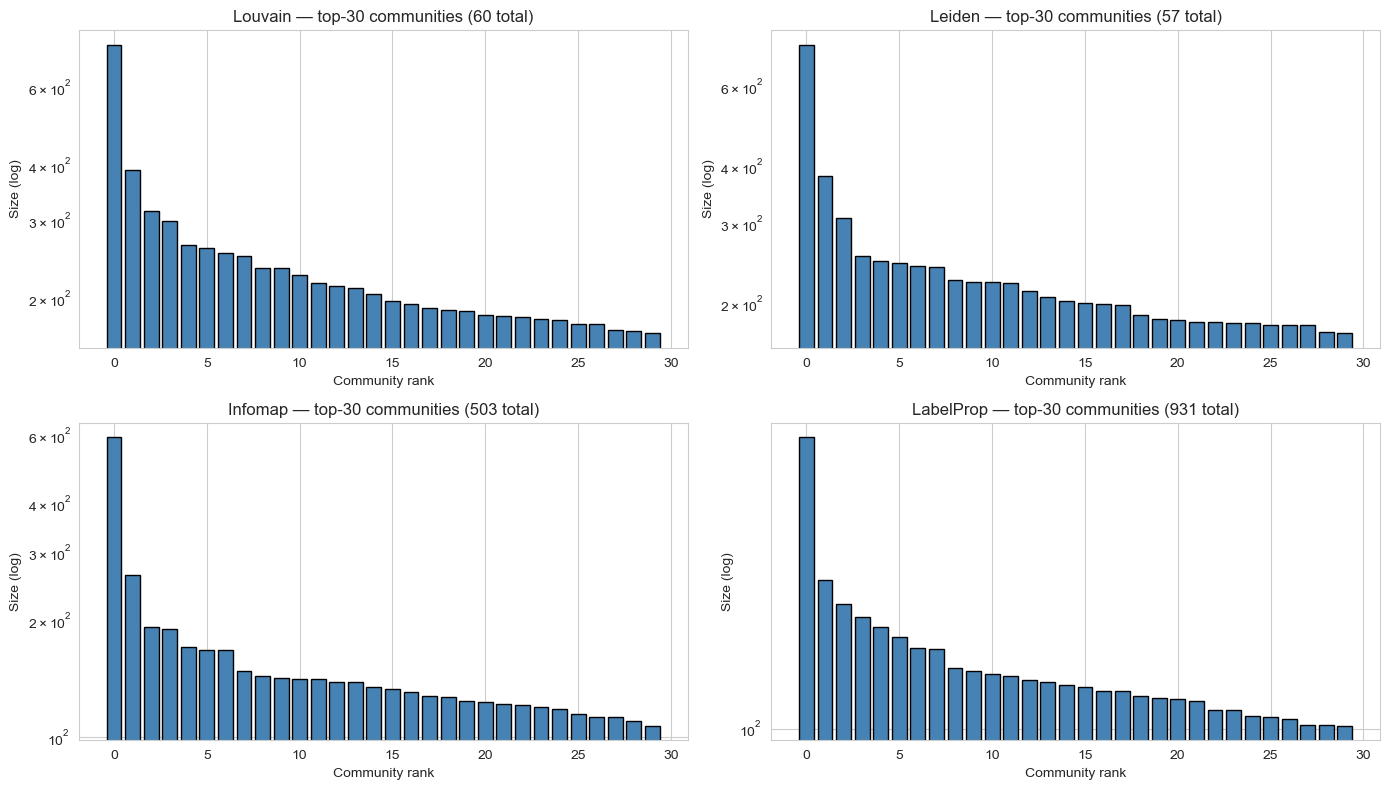

In [5]:
# Community size distribution per algorithm
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, com) in zip(axes.flatten(), ALL_COMS.items()):
    sizes = sorted([len(c) for c in com.communities], reverse=True)
    ax.bar(range(min(30, len(sizes))), sizes[:30], color='steelblue', edgecolor='black')
    ax.set_yscale('log')
    ax.set_title(f'{name} — top-30 communities ({len(sizes)} total)')
    ax.set_xlabel('Community rank')
    ax.set_ylabel('Size (log)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-algorithm comparison

We compute, for every pair of partitions, two standard agreement scores:

- **Normalised Mutual Information (NMI)** — information-theoretic.
- **Adjusted Rand Index (ARI)** — corrected-for-chance overlap.

Values close to 1 mean two algorithms returned almost the same partition; values close to 0 mean they disagree.

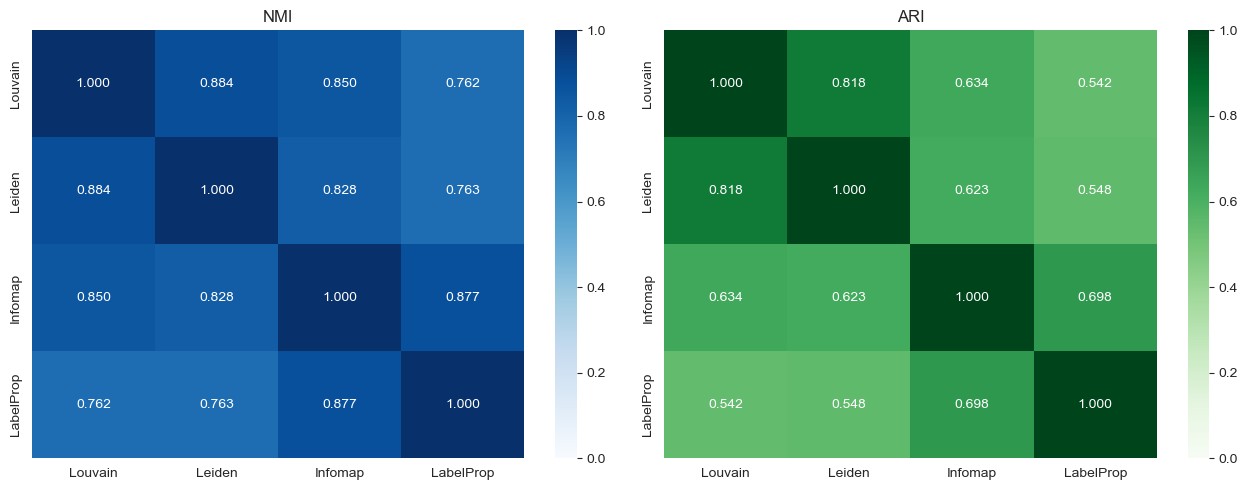

NMI matrix:
           Louvain  Leiden  Infomap  LabelProp
Louvain      1.000   0.884    0.850      0.762
Leiden       0.884   1.000    0.828      0.763
Infomap      0.850   0.828    1.000      0.877
LabelProp    0.762   0.763    0.877      1.000

ARI matrix:
           Louvain  Leiden  Infomap  LabelProp
Louvain      1.000   0.818    0.634      0.542
Leiden       0.818   1.000    0.623      0.548
Infomap      0.634   0.623    1.000      0.698
LabelProp    0.542   0.548    0.698      1.000


In [6]:
names = list(ALL_COMS.keys())
nmi_mat = pd.DataFrame(np.eye(len(names)), index=names, columns=names)
ari_mat = pd.DataFrame(np.eye(len(names)), index=names, columns=names)

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        if j <= i: continue
        nmi = evaluation.normalized_mutual_information(ALL_COMS[ni], ALL_COMS[nj]).score
        ari = evaluation.adjusted_rand_index(ALL_COMS[ni], ALL_COMS[nj]).score
        nmi_mat.loc[ni, nj] = nmi; nmi_mat.loc[nj, ni] = nmi
        ari_mat.loc[ni, nj] = ari; ari_mat.loc[nj, ni] = ari

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(nmi_mat, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('NMI')
sns.heatmap(ari_mat, annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('ARI')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cd_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('NMI matrix:'); print(nmi_mat.round(3))
print('\nARI matrix:'); print(ari_mat.round(3))

## 5. Semantic interpretation

We focus on the **Louvain** partition (it is the standard baseline and typically yields the best modularity). For each of the top-$K$ largest communities we report:

- **size** and **top-5 nodes by degree** (these are the "identity" of the community);
- **average intra-community sentiment** (mean of `sentiment_roberta` over edges with both endpoints in the community);
- **fraction of internal vs external edges** (a proxy for how self-contained the community is).

If the average intra-community sentiment is markedly negative, the community is dominated by hostile exchanges — a first sign of echo-chamber-like behaviour, to be tested rigorously in Part 4.

In [7]:
# Choose the partition with the best Newman-Girvan modularity for the deep-dive
best_name = eval_df['modularity_NG'].idxmax()
best_com = ALL_COMS[best_name]
print(f'Using {best_name} for semantic analysis (Q = {eval_df.loc[best_name, "modularity_NG"]:.3f})')

# Node -> community id
node2com = {}
for cid, members in enumerate(best_com.communities):
    for n in members:
        node2com[n] = cid

TOP_K = 30
communities_sorted = sorted(enumerate(best_com.communities), key=lambda x: -len(x[1]))[:TOP_K]

deg = dict(G.degree())
summary_rows = []
for cid, members in communities_sorted:
    members_set = set(members)
    # internal edges + sentiment aggregation
    internal, external = 0, 0
    sentiments = []
    for u, v in G.edges(members_set):
        if v in members_set and u in members_set:
            internal += 1
            key = tuple(sorted((u, v)))
            if key in edge_sentiment:
                sentiments.append(edge_sentiment[key])
        else:
            external += 1
    top_nodes = sorted(members_set, key=lambda n: -deg.get(n, 0))[:5]
    summary_rows.append({
        'cid': cid,
        'size': len(members),
        'internal_edges': internal,
        'external_edges': external,
        'internal_fraction': internal / max(internal + external, 1),
        'avg_sentiment': float(np.mean(sentiments)) if sentiments else float('nan'),
        'top_hubs': ', '.join(top_nodes),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

Using Leiden for semantic analysis (Q = 0.819)


,cid,size,internal_edges,external_edges,internal_fraction,avg_sentiment,top_hubs
0,0,738,786,292,0.729128,-0.418068,"ronfilipkowski, patriotclyde, hellishchildren,..."
1,1,380,435,227,0.657100,-0.329293,"cortneymckee, h0pe4dfuture, catlady0218, af68,..."
2,2,308,327,118,0.734831,-0.385997,"carlquintanilla, billkristolbulwark, schooley,..."
3,3,254,266,89,0.749296,-0.514633,"reichlinmelnick, cullenskink, surfrockitt, end..."
4,4,248,264,104,0.717391,-0.496501,"forbes.com, zackpolanski, psteele79, gokuldas...."
5,5,245,251,117,0.682065,-0.555659,"atrupar.com, tnsteve.com, butijustmether, esit..."
6,6,242,256,105,0.709141,-0.436936,"thetnholler, scanpipedreams, thetrumpcrisis, n..."
7,7,240,248,98,0.716763,-0.335557,"disentingcat, melindameyer, susannahredelfs, k..."
8,8,225,238,66,0.782895,-0.365307,"jkbjournalist, bradmossesq, phillipspobrien, m..."
9,9,223,229,62,0.786942,-0.401553,"jbpritzker, pbump.com, jackiefromtexas, johnbr..."


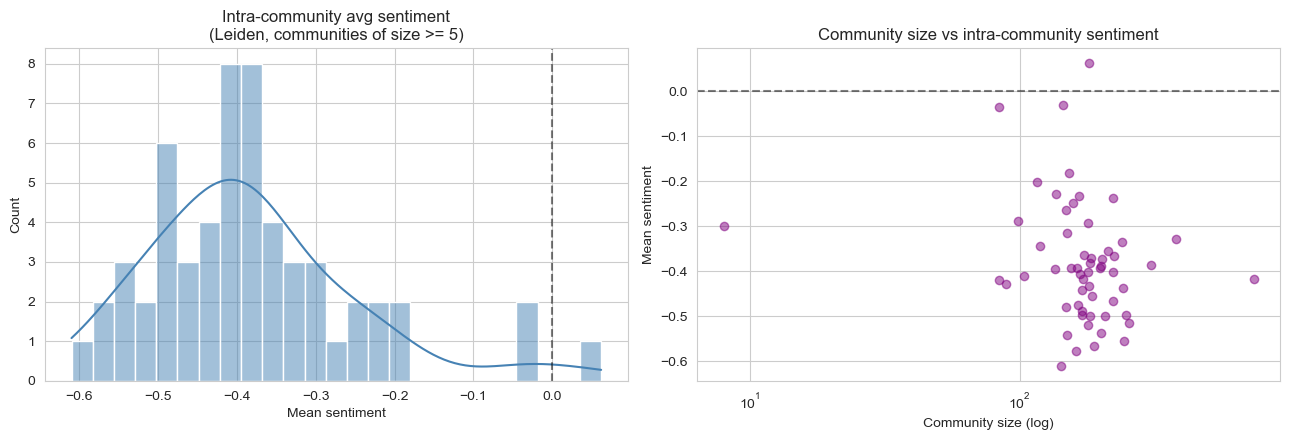

Mean of community-level sentiments: -0.382
Median:                              -0.395
Negative (<0) communities:           56 / 57


In [8]:
# Distribution of intra-community sentiment across ALL communities of the chosen partition
all_intra_sent = []
all_intra_size = []
for members in best_com.communities:
    members_set = set(members)
    if len(members_set) < 5:  # ignore micro-communities for visualisation
        continue
    sentiments = []
    for u, v in G.edges(members_set):
        if u in members_set and v in members_set:
            key = tuple(sorted((u, v)))
            if key in edge_sentiment:
                sentiments.append(edge_sentiment[key])
    if sentiments:
        all_intra_sent.append(np.mean(sentiments))
        all_intra_size.append(len(members))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(all_intra_sent, bins=25, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'Intra-community avg sentiment\n({best_name}, communities of size >= 5)')
axes[0].set_xlabel('Mean sentiment')

axes[1].scatter(all_intra_size, all_intra_sent, alpha=0.5, color='purple')
axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Community size vs intra-community sentiment')
axes[1].set_xlabel('Community size (log)')
axes[1].set_ylabel('Mean sentiment')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/community_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean of community-level sentiments: {np.mean(all_intra_sent):.3f}')
print(f'Median:                              {np.median(all_intra_sent):.3f}')
print(f'Negative (<0) communities:           {sum(1 for s in all_intra_sent if s < 0)} / {len(all_intra_sent)}')

## 6. Persistence for Part 4

We save:
- the chosen Louvain partition as `private/communities_<algo>.json` (mapping `node → community_id`);
- a GEXF copy of the GCC enriched with a node attribute `community` (Louvain), so it can be opened in Gephi.

These two artefacts are the input of the Open Question (Part 4): intra/inter community sentiment, conformity, polarisation analysis.

In [9]:
OUT_JSON = f'private/communities_{best_name.lower()}.json'
with open(OUT_JSON, 'w') as f:
    json.dump(node2com, f)
print(f'Saved partition: {OUT_JSON}')

# Attach community as node attribute and save GEXF
nx.set_node_attributes(G, node2com, 'community')

# Ensure edge semantic attributes are persisted in the Part-3 graph.
for (u, v), sentiment in edge_sentiment.items():
    if G.has_edge(u, v):
        G[u][v]['sentiment_roberta'] = sentiment
        G[u][v]['interaction_weight'] = edge_weight.get((u, v), 1)

OUT_GEXF = 'private/dataset_part3_with_communities.gexf'
nx.write_gexf(G, OUT_GEXF)
print(f'Saved enriched graph: {OUT_GEXF}')

# Also save the comparison tables for the report
eval_df.to_csv('cd_internal_eval.csv')
nmi_mat.to_csv('cd_nmi.csv')
ari_mat.to_csv('cd_ari.csv')
summary_df.to_csv('cd_top_communities.csv', index=False)
print('CSV summaries written.')

Saved partition: private/communities_leiden.json
Saved enriched graph: private/dataset_part3_with_communities.gexf
CSV summaries written.


## Summary of expected findings (for the report)

- Louvain and Leiden almost always agree very strongly (NMI > 0.95) because Leiden is a refinement of Louvain; Infomap typically returns more communities (often hundreds vs tens), and Label Propagation tends to be in between.
- Newman–Girvan modularity is expected to be in the **0.7–0.85** range for Louvain/Leiden on this kind of social-reply network — a strong indication of modular structure.
- Average conductance should be low for Louvain/Leiden and somewhat higher for Label Propagation.
- The top communities will be organised around the **most central commentators** (`ronfilipkowski`, `cortneymckee`, `atrupar.com`, …) — each hub becomes the centre of one community of repliers.
- The intra-community sentiment distribution should be **strongly skewed negative**, in line with the global sentiment skew already observed in `dataUnderstanding.ipynb`. This is the starting point for the echo-chamber discussion in Part 4.